In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [22]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)

test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [23]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_name = train_data.target_names

In [24]:
print("Training documents: ",len(X_train_text))
print("Testing documents: ",len(X_test_text))
print("Number of classes: ",len(class_name))

Training documents:  11314
Testing documents:  7532
Number of classes:  20


In [25]:
vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [26]:
print("Training feature matrix: ",X_train.shape)
print("Testing feature matrix: ",X_test.shape)

Training feature matrix:  (11314, 39115)
Testing feature matrix:  (7532, 39115)


In [27]:
mnb = MultinomialNB()

mnb.fit(
    X_train,
    y_train
)

y_pred_mnb = mnb.predict(X_test)

In [28]:
binary_vectorizer = CountVectorizer(
    stop_words = "english",
    min_df=2,
    binary=True
)

X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)

X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [29]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(X_test_binary)

In [30]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average="weighted", zero_division=0)
mnb_recall = recall_score(y_test, y_pred_mnb, average="weighted", zero_division=0)
mnb_f1 = f1_score(y_test, y_pred_mnb, average="weighted", zero_division=0)

bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average="weighted", zero_division=0)
bnb_recall = recall_score(y_test, y_pred_bnb, average="weighted", zero_division=0)
bnb_f1 = f1_score(y_test, y_pred_bnb, average="weighted", zero_division=0)

In [31]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Bernoulli Naive Bayes"
    ],
    "Accuracy": [
        mnb_accuracy,
        bnb_accuracy
    ],
    "Precision": [
        mnb_precision,
        bnb_precision
    ],
    "Recall": [
        mnb_recall,
        bnb_recall
    ],
    "F1 Score": [
        mnb_f1,
        bnb_f1
    ]
})

print("\nModel Comparison:")
print(results.round(4))


Model Comparison:
                     Model  Accuracy  Precision  Recall  F1 Score
0  Multinomial Naive Bayes    0.6511     0.6425  0.6511    0.6296
1    Bernoulli Naive Bayes    0.4851     0.6270  0.4851    0.4808


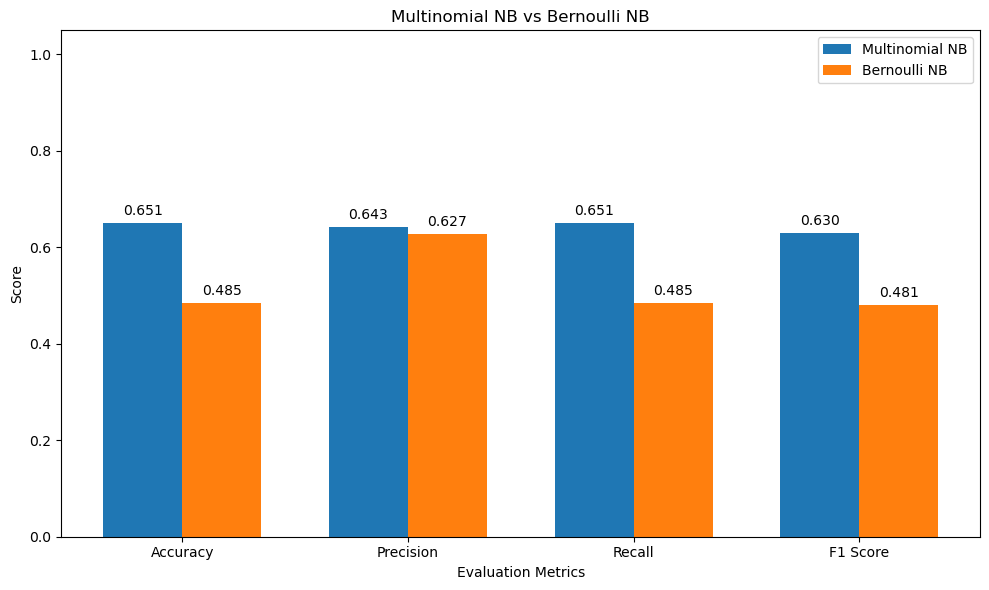

In [33]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

mnb_scores = [
    mnb_accuracy,
    mnb_precision,
    mnb_recall,
    mnb_f1
]

bnb_scores = [
    bnb_accuracy,
    bnb_precision,
    bnb_recall,
    bnb_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    mnb_scores,
    width,
    label="Multinomial NB"
)

bars2 = plt.bar(
    x + width/2,
    bnb_scores,
    width,
    label="Bernoulli NB"
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Multinomial NB vs Bernoulli NB")
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()